In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path

MAT_PATH = Path('../curves/matlab/HV_disc_bkgSNOLAB_detSNOLAB_cons.mat')
OUT_DIR = Path('../curves/matlab/outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

mat = sio.loadmat(MAT_PATH)

def print_structure(obj, name="", indent=0):
    pad = "  " * indent
    if isinstance(obj, np.ndarray):
        if obj.dtype.names:
            print(f"{pad}{name}: struct fields={obj.dtype.names}, shape={obj.shape}")
            for field in obj.dtype.names:
                val = obj[field] if obj.ndim == 0 else obj.flat[0][field]
                print_structure(val, field, indent + 1)
        else:
            print(f"{pad}{name}: ndarray dtype={obj.dtype}, shape={obj.shape}")
    elif isinstance(obj, dict):
        print(f"{pad}{name}: dict keys={list(obj.keys())}")
        for k, v in obj.items():
            print_structure(v, k, indent + 1)
    else:
        print(f"{pad}{name}: {type(obj).__name__} = {obj!r}")

keys = [k for k in mat.keys() if not k.startswith("_")]
print(f"Top-level keys: {keys}\n")
for k in keys:
    print_structure(mat[k], k)

Top-level keys: ['Bkg', 'Det', 'ExpAnal', 'RawBkg', 'Sim', 'WIMP', 'mask_Bkg', 'mask_WIMP', 'OICL', 'OISetup', 'PRL']

Bkg: ndarray dtype=object, shape=(2, 1)
Det: struct fields=('name', 'lgcElement', 'A', 'Z', 'rhoD_m', 'rhoD_n', 'Eeh', 'Egap', 'Fano_ER', 'Fano_NR', 'Er_NRDisp', 'Td', 'gC_v', 'fUThK', 'Mn', 'h', 'ro', 'ri', 'vol', 'voli', 'SAr', 'SAz', 'SAt', 'M', 'Tc', 'WAlTransmission', 'scatteringLength', 'tauEff', 'fAl', 'tauCollect', 'resPt_sig0', 'resPt_fpt', 'Pt_Trigger', 'scatteringTime', 'tauPosition', 'sigmaPosition', 'fphonon_xyz', 'resPz_sig0', 'resPz_fpt', 'nPi', 'nPo', 'resPr_fpt', 'cPr_type', 'resPr_sig0', 'Er_NRQThresh', 'Vb', 'dPzdPt_max', 'f_PrSharing', 'lgc_ActiveVeto', 'lgc_2side', 'NRFV', 'ERFV', 'SEFV', 'trapProbability', 'impionProbability', 'surfimpionProbability', 'Rdark', 'tsep', 'linToLogEnergy', 'yieldfunction'), shape=(1, 2)
  name: ndarray dtype=<U2, shape=(1,)
  lgcElement: ndarray dtype=uint8, shape=(1, 1)
  A: ndarray dtype=float64, shape=(1, 1)
  Z: n

Inspect the printed structure above to confirm where `fccl` and `p90median` live (e.g. nested under a top-level struct). Adjust the field-access chain in the next cell to match before running it.

In [2]:
# Reload with squeeze_me/struct_as_record=False for clean dot-attribute access to nested structs.
mat2 = sio.loadmat(MAT_PATH, squeeze_me=True, struct_as_record=False)

# Combined Ge+Si ("Mixed") Feldman-Cousins p90 median limit curve.
prl = mat2['PRL']
x_data = np.asarray(prl.Mass, dtype=float)
y_data = np.asarray(prl.XSsi_p90median, dtype=float)

print(f"x_data: shape={x_data.shape}, range=({x_data.min():.3g}, {x_data.max():.3g})")
print(f"y_data: shape={y_data.shape}, range=({y_data.min():.3g}, {y_data.max():.3g})")

x_data: shape=(50,), range=(0.452, 30)
y_data: shape=(50,), range=(nan, nan)


Saved 50 points -> ../curves/matlab/outputs/scdms_hv_cd2_p90median.csv


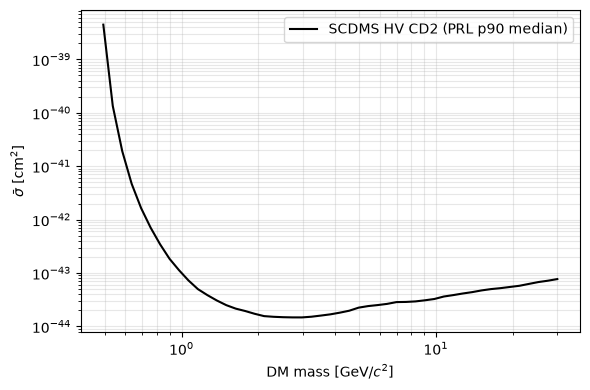

In [3]:
CURVE_NAME = 'scdms_hv_cd2_p90median'  # change per curve

out_path = OUT_DIR / f'{CURVE_NAME}.csv'
np.savetxt(out_path, np.column_stack([x_data, y_data]),
           delimiter=',', header='x_GeV_per_c2,y_cm2', comments='')
print(f'Saved {len(x_data)} points -> {out_path}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_data, y_data, color='black', lw=1.5, label='SCDMS HV CD2 (PRL p90 median)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'DM mass [GeV/$c^2$]')
ax.set_ylabel(r'$\bar{\sigma}$ [cm$^2$]')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()